In [4]:
from datasets import load_dataset

dataset = load_dataset("abisee/cnn_dailymail", "3.0.0")

README.md:   0%|          | 0.00/15.6k [00:00<?, ?B/s]

C:\Users\ADMIN\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ADMIN\.cache\huggingface\hub\datasets--abisee--cnn_dailymail. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

3.0.0/validation-00000-of-00001.parquet:   0%|          | 0.00/34.7M [00:00<?, ?B/s]

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

In [5]:
train_data = dataset['train']
validation_data = dataset['validation']
test_data = dataset['test']

In [6]:
import pandas as pd

train_df = pd.DataFrame(train_data)
validation_df = pd.DataFrame(validation_data)
test_df = pd.DataFrame(test_data)

In [9]:
train_df.head()

,article,highlights,id
0,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...,42c027e4ff9730fbb3de84c1af0d2c506e41c3e4
1,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...,ee8871b15c50d0db17b0179a6d2beab35065f1e9
2,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...","NEW: ""I thought I was going to die,"" driver sa...",06352019a19ae31e527f37f7571c6dd7f0c5da37
3,WASHINGTON (CNN) -- Doctors removed five small...,"Five small polyps found during procedure; ""non...",24521a2abb2e1f5e34e6824e0f9e56904a2b0e88
4,(CNN) -- The National Football League has ind...,"NEW: NFL chief, Atlanta Falcons owner critical...",7fe70cc8b12fab2d0a258fababf7d9c6b5e1262a


In [10]:
train_df = train_df.drop('id',axis=1)

In [11]:
train_df.head()

,article,highlights
0,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...
1,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...
2,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...","NEW: ""I thought I was going to die,"" driver sa..."
3,WASHINGTON (CNN) -- Doctors removed five small...,"Five small polyps found during procedure; ""non..."
4,(CNN) -- The National Football League has ind...,"NEW: NFL chief, Atlanta Falcons owner critical..."


In [12]:
train_df.isnull().sum()

article       0
highlights    0
dtype: int64

In [15]:
train_df.duplicated().sum()

np.int64(3098)

In [16]:
train_df = train_df.drop_duplicates()

In [17]:
train_df.shape

(284015, 2)

In [18]:
df = train_df.sample(20000)

In [19]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [20]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Remove special characters & punctuation (keep letters & spaces)
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 5. Tokenization
    tokens = word_tokenize(text)

    # 6. Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]

    # 7. Stemming
    tokens = [stemmer.stem(t) for t in tokens]

    return tokens  # returns list of clean tokens

In [21]:
print("Preprocessing articles...")
df['article_tokens'] = df['article'].apply(preprocess_text)

print("Preprocessing summaries...")
df['summary_tokens'] = df['highlights'].apply(preprocess_text)

print("Done!")


Preprocessing articles...
Preprocessing summaries...
Done!
                                          article_tokens  \
43693  [cnn, start, swim, sunni, afternoon, florida, ...   
56459  [cnn, deal, suit, lo, angel, clipper, owner, d...   
82250  [cnn, american, exercis, past, still, work, en...   

                                          summary_tokens  
43693  [bite, within, minut, author, say, neither, ma...  
56459  [onset, want, sell, lo, angel, clipper, sterl,...  
82250  [survey, found, less, half, american, adult, g...  


In [ ]:
# Joined clean text (useful for TF-IDF, vectorizers, etc.)
df['article_clean'] = df['article_tokens'].apply(lambda x: ' '.join(x))
df['summary_clean'] = df['summary_tokens'].apply(lambda x: ' '.join(x))



In [25]:
df.head()

,article,highlights,article_tokens,summary_tokens,article_clean,summary_clean
43693,(CNN) -- It started with a swim on a sunny aft...,"The bites were within minutes of each other, a...","[cnn, start, swim, sunni, afternoon, florida, ...","[bite, within, minut, author, say, neither, ma...",cnn start swim sunni afternoon florida coast l...,bite within minut author say neither man injur...
56459,(CNN) -- The deal is off. The suit is on. Los ...,"From the onset, I did not want to sell the Los...","[cnn, deal, suit, lo, angel, clipper, owner, d...","[onset, want, sell, lo, angel, clipper, sterl,...",cnn deal suit lo angel clipper owner donald st...,onset want sell lo angel clipper sterl write e...
82250,(CNN) -- Americans are exercising more than in...,Survey found less than half of American adults...,"[cnn, american, exercis, past, still, work, en...","[survey, found, less, half, american, adult, g...",cnn american exercis past still work enough me...,survey found less half american adult get regu...
137192,Fox chief Kevin Reilly says the show will 'lik...,Fox chief Kevin Reilly says the show will 'lik...,"[fox, chief, kevin, reilli, say, show, like, g...","[fox, chief, kevin, reilli, say, show, like, g...",fox chief kevin reilli say show like go back t...,fox chief kevin reilli say show like go back t...
223538,The Football Association are poring over video...,Branislav Ivanovic may face retrospective disc...,"[footbal, associ, pore, video, footag, branisl...","[branislav, ivanov, may, face, retrospect, dis...",footbal associ pore video footag branislav iva...,branislav ivanov may face retrospect disciplin...


In [26]:
import pandas as pd
from collections import Counter
import numpy as np
df['article_char_len'] = df['article_clean'].apply(len)
df['summary_char_len'] = df['summary_clean'].apply(len)
df['article_word_count'] = df['article_tokens'].apply(len)
df['summary_word_count'] = df['summary_tokens'].apply(len)

df['article_sentence_count'] = df['article'].apply(
    lambda x: len(str(x).split('.'))
)
df['summary_sentence_count'] = df['highlights'].apply(
    lambda x: len(str(x).split('.'))
)

df['avg_word_length_article'] = df['article_tokens'].apply(
    lambda x: np.mean([len(word) for word in x]) if len(x) > 0 else 0
)

# compression ratio
df['compression_ratio'] = (
    df['summary_word_count'] / df['article_word_count']
)

# ==============================
# UNIQUE WORD FEATURES
# ==============================

df['unique_article_words'] = df['article_tokens'].apply(
    lambda x: len(set(x))
)

df['unique_summary_words'] = df['summary_tokens'].apply(
    lambda x: len(set(x))
)

# lexical diversity
df['article_lexical_diversity'] = (
    df['unique_article_words'] / df['article_word_count']
)

# ==============================
# REPEATED WORD FEATURES
# ==============================

def repeated_word_count(tokens):
    word_counts = Counter(tokens)
    repeated = [word for word, count in word_counts.items() if count > 1]
    return len(repeated)

df['repeated_words_article'] = df['article_tokens'].apply(
    repeated_word_count
)

# ==============================
# MOST COMMON WORDS
# ==============================

all_words = []

for tokens in df['article_tokens']:
    all_words.extend(tokens)

word_freq = Counter(all_words)

# top 20 most common words
top_20_words = word_freq.most_common(20)

print("Top 20 Most Common Words:\n")
print(top_20_words)

# ==============================
# ARTICLE DUPLICATE CHECK
# ==============================

duplicate_articles = df.duplicated(subset=['article_clean']).sum()

print("\nDuplicate Articles:", duplicate_articles)

# ==============================
# SUMMARY DUPLICATE CHECK
# ==============================

duplicate_summaries = df.duplicated(
    subset=['summary_clean']
).sum()

print("Duplicate Summaries:", duplicate_summaries)


longest_articles = df.nlargest(
    5,
    'article_word_count'
)[['article_word_count', 'article']]

print("\nLongest Articles:")
print(longest_articles)


shortest_articles = df.nsmallest(
    5,
    'article_word_count'
)[['article_word_count', 'article']]



Top 20 Most Common Words:

[('said', 90946), ('year', 36608), ('one', 33394), ('time', 26398), ('would', 25023), ('peopl', 24902), ('also', 24654), ('say', 24500), ('new', 23411), ('two', 21834), ('last', 21144), ('mr', 20947), ('told', 20112), ('like', 19627), ('polic', 19472), ('day', 18658), ('first', 18377), ('use', 18172), ('report', 17550), ('could', 17533)]

Duplicate Articles: 0
Duplicate Summaries: 28

Longest Articles:
        article_word_count                                            article
239945                1142  Two people were killed and more than 100,000 h...
153937                1140  By . Mike Dickson . PUBLISHED: . 19:18 EST, 9 ...
215754                1140  It's Breaking 'bout time that the immensely po...
216719                1107  The Duchess of Cambridge joined Princes Willia...
240820                1102  The United States soccer team may have been gi...

Shortest Articles:
        article_word_count                                            article
1

In [28]:
df.head()

,article,highlights,article_tokens,summary_tokens,article_clean,summary_clean,article_char_len,summary_char_len,article_word_count,summary_word_count,article_sentence_count,summary_sentence_count,avg_word_length_article,compression_ratio,unique_article_words,unique_summary_words,article_lexical_diversity,repeated_words_article
43693,(CNN) -- It started with a swim on a sunny aft...,"The bites were within minutes of each other, a...","[cnn, start, swim, sunni, afternoon, florida, ...","[bite, within, minut, author, say, neither, ma...",cnn start swim sunni afternoon florida coast l...,bite within minut author say neither man injur...,668,129,108,20,15,4,5.194444,0.185185,78,18,0.722222,20
56459,(CNN) -- The deal is off. The suit is on. Los ...,"From the onset, I did not want to sell the Los...","[cnn, deal, suit, lo, angel, clipper, owner, d...","[onset, want, sell, lo, angel, clipper, sterl,...",cnn deal suit lo angel clipper owner donald st...,onset want sell lo angel clipper sterl write e...,1623,193,258,34,32,4,5.294574,0.131783,167,29,0.647287,44
82250,(CNN) -- Americans are exercising more than in...,Survey found less than half of American adults...,"[cnn, american, exercis, past, still, work, en...","[survey, found, less, half, american, adult, g...",cnn american exercis past still work enough me...,survey found less half american adult get regu...,1532,167,236,26,34,5,5.495763,0.110169,132,24,0.559322,46
137192,Fox chief Kevin Reilly says the show will 'lik...,Fox chief Kevin Reilly says the show will 'lik...,"[fox, chief, kevin, reilli, say, show, like, g...","[fox, chief, kevin, reilli, say, show, like, g...",fox chief kevin reilli say show like go back t...,fox chief kevin reilli say show like go back t...,4104,384,686,67,78,5,4.983965,0.097668,353,59,0.514577,121
223538,The Football Association are poring over video...,Branislav Ivanovic may face retrospective disc...,"[footbal, associ, pore, video, footag, branisl...","[branislav, ivanov, may, face, retrospect, dis...",footbal associ pore video footag branislav iva...,branislav ivanov may face retrospect disciplin...,1883,150,302,21,28,4,5.238411,0.069536,191,18,0.632450,57


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

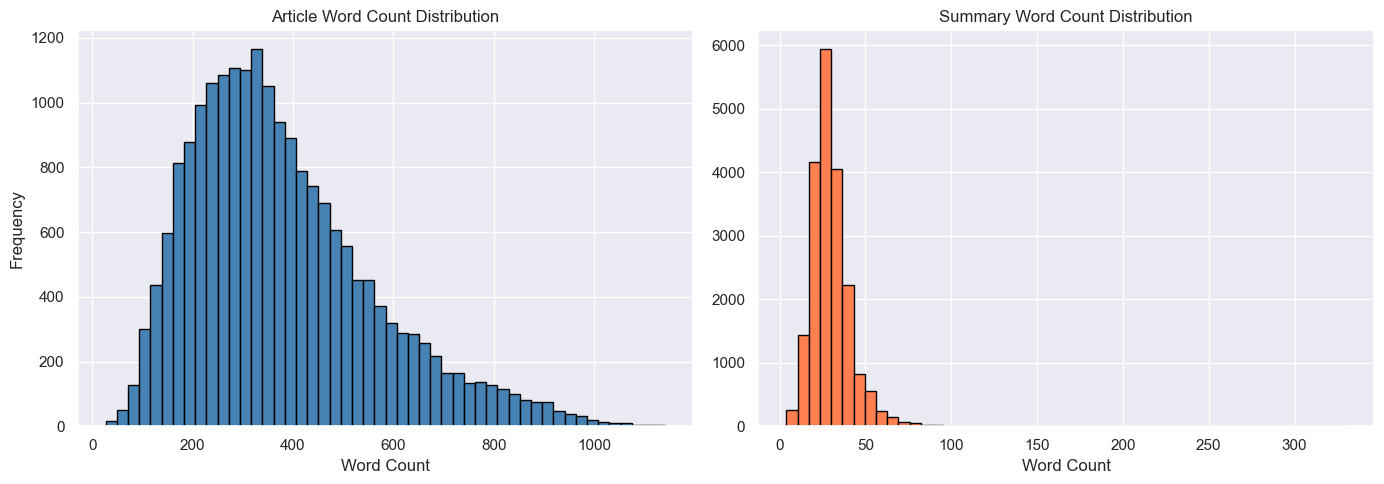

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['article_word_count'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Article Word Count Distribution')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['summary_word_count'], bins=50, color='coral', edgecolor='black')
axes[1].set_title('Summary Word Count Distribution')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.show()

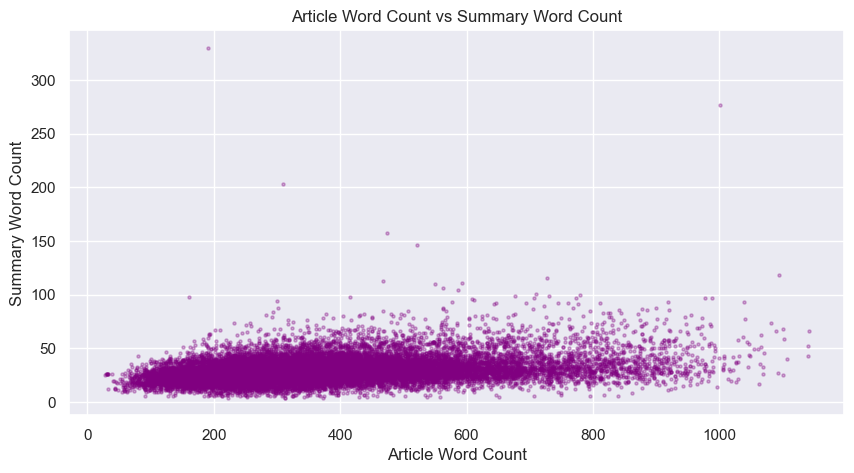

In [31]:
plt.figure(figsize=(10, 5))
plt.scatter(df['article_word_count'], df['summary_word_count'],
            alpha=0.3, color='purple', s=5)
plt.title('Article Word Count vs Summary Word Count')
plt.xlabel('Article Word Count')
plt.ylabel('Summary Word Count')
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3888\3036563771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words), y=list(counts), palette='viridis')


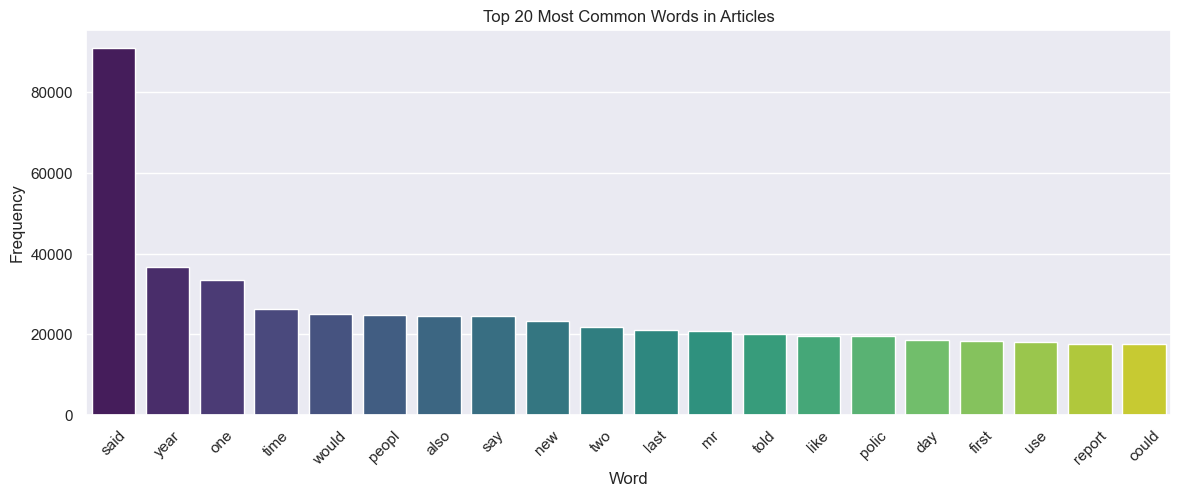

In [32]:
words, counts = zip(*top_20_words)

plt.figure(figsize=(14, 5))
sns.barplot(x=list(words), y=list(counts), palette='viridis')
plt.title('Top 20 Most Common Words in Articles')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

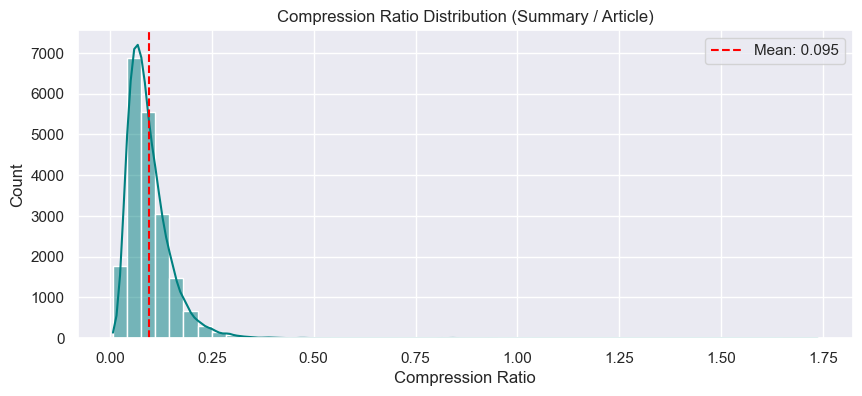

In [33]:
plt.figure(figsize=(10, 4))
sns.histplot(df['compression_ratio'], bins=50, color='teal', kde=True)
plt.title('Compression Ratio Distribution (Summary / Article)')
plt.xlabel('Compression Ratio')
plt.axvline(df['compression_ratio'].mean(), color='red',
            linestyle='--', label=f"Mean: {df['compression_ratio'].mean():.3f}")
plt.legend()
plt.show()

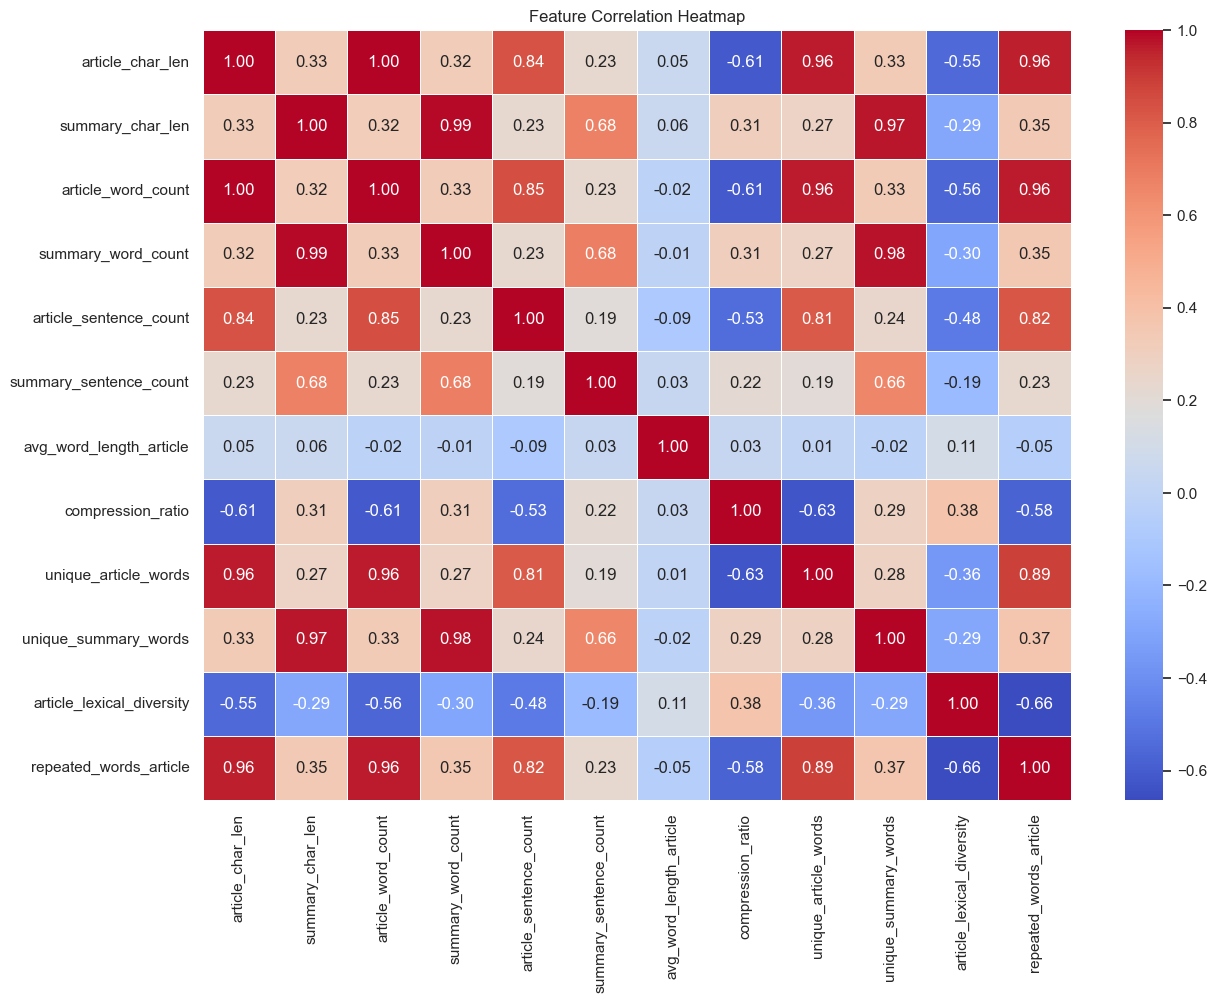

In [34]:
numeric_cols = [
    'article_char_len', 'summary_char_len',
    'article_word_count', 'summary_word_count',
    'article_sentence_count', 'summary_sentence_count',
    'avg_word_length_article', 'compression_ratio',
    'unique_article_words', 'unique_summary_words',
    'article_lexical_diversity', 'repeated_words_article'
]

plt.figure(figsize=(14, 10))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [35]:
df[numeric_cols].describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
article_char_len,20000.000000,2411.425200,1167.386542,163.000000,1544.750000,2188.000000,3040.000000,7429.000000
summary_char_len,20000.000000,189.357650,73.895448,22.000000,142.000000,180.000000,222.000000,2078.000000
article_word_count,20000.000000,379.109550,182.782748,27.000000,244.000000,345.000000,478.000000,1142.000000
summary_word_count,20000.000000,29.925300,11.592197,4.000000,23.000000,28.000000,35.000000,330.000000
article_sentence_count,20000.000000,42.854600,25.057543,3.000000,25.000000,37.000000,54.000000,237.000000
summary_sentence_count,20000.000000,4.838300,1.590842,1.000000,4.000000,5.000000,5.000000,46.000000
avg_word_length_article,20000.000000,5.365199,0.230240,4.390071,5.214631,5.364501,5.516522,9.602151
compression_ratio,20000.000000,0.095035,0.054611,0.007143,0.059081,0.083110,0.117647,1.736842
unique_article_words,20000.000000,224.421150,95.029656,25.000000,154.000000,208.000000,281.000000,713.000000
unique_summary_words,20000.000000,27.046000,9.623394,4.000000,21.000000,26.000000,31.000000,257.000000


In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.sparse import hstack, csr_matrix
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [39]:

y = df['compression_ratio'].values

print("Target (compression_ratio) stats:")
print(pd.Series(y).describe())

Target (compression_ratio) stats:
count    20000.000000
mean         0.095035
std          0.054611
min          0.007143
25%          0.059081
50%          0.083110
75%          0.117647
max          1.736842
dtype: float64


In [40]:
tfidf = TfidfVectorizer(
    max_features=5000,   # top 5000 terms
    ngram_range=(1, 2),  # unigrams + bigrams
    min_df=5,            # ignore very rare terms
    max_df=0.95          # ignore very common terms
)

X_tfidf = tfidf.fit_transform(df['article_clean'])
print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (20000, 5000)


In [41]:
numeric_features = [
    'article_char_len',
    'article_word_count',
    'article_sentence_count',
    'avg_word_length_article',
    'unique_article_words',
    'article_lexical_diversity',
    'repeated_words_article'
]

X_numeric = csr_matrix(df[numeric_features].fillna(0).values)
print("Numeric features shape:", X_numeric.shape)

Numeric features shape: (20000, 7)


In [42]:
X_combined = hstack([X_tfidf, X_numeric])
print("Combined feature matrix shape:", X_combined.shape)


Combined feature matrix shape: (20000, 5007)


In [43]:
# 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_combined, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train size :", X_train.shape)
print("Val size   :", X_val.shape)
print("Test size  :", X_test.shape)

Train size : (14000, 5007)
Val size   : (3000, 5007)
Test size  : (3000, 5007)


In [44]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Random Forest training done!")

Random Forest training done!


In [45]:
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'   # fast on Colab CPU/GPU
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)
print("XGBoost training done!")

[0]	validation_0-rmse:0.04667
[50]	validation_0-rmse:0.03099
[100]	validation_0-rmse:0.03106
[150]	validation_0-rmse:0.03106
[199]	validation_0-rmse:0.03107
XGBoost training done!


In [47]:
def evaluate_model(name, model, X, y_true):
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{name}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    return y_pred

print("===== VALIDATION SET =====")
rf_val_preds  = evaluate_model("Random Forest", rf_model,  X_val, y_val)
xgb_val_preds = evaluate_model("XGBoost",       xgb_model, X_val, y_val)

print("\n===== TEST SET =====")
rf_test_preds  = evaluate_model("Random Forest", rf_model,  X_test, y_test)
xgb_test_preds = evaluate_model("XGBoost",       xgb_model, X_test, y_test)

===== VALIDATION SET =====

Random Forest
  RMSE : 0.0312
  MAE  : 0.0224
  R²   : 0.6083

XGBoost
  RMSE : 0.0317
  MAE  : 0.0223
  R²   : 0.5946

===== TEST SET =====

Random Forest
  RMSE : 0.0341
  MAE  : 0.0234
  R²   : 0.6365

XGBoost
  RMSE : 0.0340
  MAE  : 0.0233
  R²   : 0.6382


In [48]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Val RMSE':  [
        np.sqrt(mean_squared_error(y_val, rf_val_preds)),
        np.sqrt(mean_squared_error(y_val, xgb_val_preds))
    ],
    'Val MAE': [
        mean_absolute_error(y_val, rf_val_preds),
        mean_absolute_error(y_val, xgb_val_preds)
    ],
    'Val R²': [
        r2_score(y_val, rf_val_preds),
        r2_score(y_val, xgb_val_preds)
    ],
    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test, rf_test_preds)),
        np.sqrt(mean_squared_error(y_test, xgb_test_preds))
    ],
    'Test R²': [
        r2_score(y_test, rf_test_preds),
        r2_score(y_test, xgb_test_preds)
    ]
})

print(results.to_string(index=False))

        Model  Val RMSE  Val MAE   Val R²  Test RMSE  Test R²
Random Forest  0.031195 0.022412 0.608307   0.034100 0.636472
      XGBoost  0.031736 0.022270 0.594605   0.034021 0.638155


In [53]:
# ==========================================
# WORD2VEC + RANDOM FOREST + XGBOOST
# ==========================================

import numpy as np
import pandas as pd

from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
w2v_model = Word2Vec(
    sentences=df['article_tokens'],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

# ==========================================
# FUNCTION TO CREATE DOCUMENT VECTOR
# ==========================================

def document_vector(tokens):

    vectors = []

    for word in tokens:

        if word in w2v_model.wv:
            vectors.append(w2v_model.wv[word])

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)

# ==========================================
# CREATE FEATURE MATRIX
# ==========================================

X = np.array([
    document_vector(tokens)
    for tokens in df['article_tokens']
])

# ==========================================
# TARGET VARIABLE
# ==========================================

# Example target
# You can change this later

y = df['compression_ratio']

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# RANDOM FOREST
# ==========================================

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# ==========================================
# XGBOOST
# ==========================================

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

# ==========================================
# EVALUATION FUNCTION
# ==========================================

def evaluate_model(y_true, y_pred, model_name):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R²   : {r2:.4f}")

# ==========================================
# RESULTS
# ==========================================

evaluate_model(y_test, rf_pred, "Random Forest")

evaluate_model(y_test, xgb_pred, "XGBoost")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'



Random Forest
RMSE : 0.0429
MAE  : 0.0314
R²   : 0.2875

XGBoost
RMSE : 0.0433
MAE  : 0.0318
R²   : 0.2760


Generating extractive summaries...
Done!
                                                 article  \
43693  (CNN) -- It started with a swim on a sunny aft...   
56459  (CNN) -- The deal is off. The suit is on. Los ...   
82250  (CNN) -- Americans are exercising more than in...   

                                              highlights  \
43693  The bites were within minutes of each other, a...   
56459  From the onset, I did not want to sell the Los...   
82250  Survey found less than half of American adults...   

                                       predicted_summary  
43693  The incidents occurred Saturday afternoon off ...  
56459  Los Angeles Clippers owner Donald Sterling is ...  
82250  From 2001 to 2005, the number of women who sai...  

ROUGE Scores (mean over 1000 samples):
rouge1    0.3254
rouge2    0.1231
rougeL    0.2106
dtype: float64


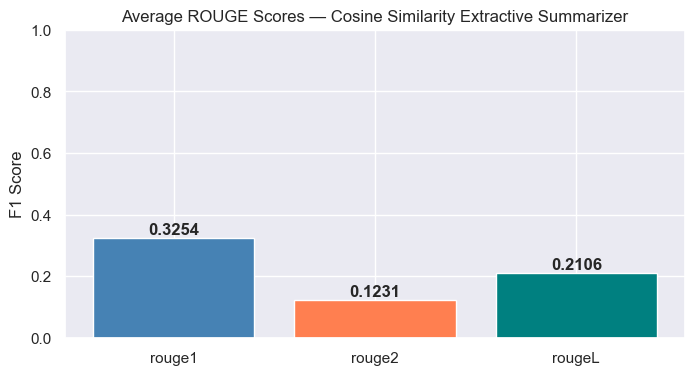

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
def extractive_summary(article, top_n=3):
    # 1. Split article into sentences
    sentences = [s.strip() for s in article.split('.') if len(s.strip()) > 20]

    if len(sentences) == 0:
        return ""

    if len(sentences) <= top_n:
        return ' '.join(sentences)

    # 2. TF-IDF vectorize all sentences + full article
    docs = sentences + [article]
    tfidf = TfidfVectorizer(stop_words='english')

    try:
        tfidf_matrix = tfidf.fit_transform(docs)
    except:
        return ' '.join(sentences[:top_n])

    # 3. Cosine similarity of each sentence vs full article
    article_vector   = tfidf_matrix[-1]       # last row = full article
    sentence_vectors = tfidf_matrix[:-1]      # all rows except last

    scores = cosine_similarity(sentence_vectors, article_vector).flatten()

    # 4. Pick top_n sentences by score
    top_indices = np.argsort(scores)[::-1][:top_n]
    top_indices = sorted(top_indices)          # restore original order

    summary = '. '.join([sentences[i] for i in top_indices])
    return summary
print("Generating extractive summaries...")

df['predicted_summary'] = df['article'].apply(
    lambda x: extractive_summary(x, top_n=3)
)

print("Done!")
print(df[['article', 'highlights', 'predicted_summary']].head(3))
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

def compute_rouge(predicted, reference):
    scores = scorer.score(predicted, reference)
    return {
        'rouge1': scores['rouge1'].fmeasure,
        'rouge2': scores['rouge2'].fmeasure,
        'rougeL': scores['rougeL'].fmeasure
    }

# Apply on sample of 1000 rows (faster)
sample_df = df.sample(1000, random_state=42).copy()
sample_df['predicted_summary'] = sample_df['article'].apply(
    lambda x: extractive_summary(x, top_n=3)
)

rouge_scores = sample_df.apply(
    lambda row: compute_rouge(row['predicted_summary'], row['highlights']),
    axis=1
)

rouge_df = pd.DataFrame(rouge_scores.tolist())
print("\nROUGE Scores (mean over 1000 samples):")
print(rouge_df.mean().round(4))
import matplotlib.pyplot as plt

means = rouge_df.mean()

plt.figure(figsize=(8, 4))
plt.bar(means.index, means.values, color=['steelblue', 'coral', 'teal'])
plt.title('Average ROUGE Scores — Cosine Similarity Extractive Summarizer')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
for i, v in enumerate(means.values):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.show()

In [57]:
def cosine_tfidf_summary(article, top_n=3):
    # split into sentences
    sentences = [s.strip() for s in article.split('.') 
                 if len(s.strip()) > 20]

    if len(sentences) == 0:
        return ""
    if len(sentences) <= top_n:
        return '. '.join(sentences) + '.'

    # build tfidf matrix: sentences + full article
    docs = sentences + [article]
    tfidf = TfidfVectorizer(
        stop_words='english',
        ngram_range=(1, 2),
        max_features=10000
    )

    try:
        matrix = tfidf.fit_transform(docs)
    except:
        return '. '.join(sentences[:top_n]) + '.'

    # cosine similarity of each sentence vs full article
    article_vec    = matrix[-1]
    sentence_vecs  = matrix[:-1]
    scores         = cosine_similarity(sentence_vecs, article_vec).flatten()

    # position bias — boost first & last sentences
    for i in range(len(scores)):
        position = i / len(sentences)
        if position < 0.15:       # first 15% of article
            scores[i] *= 1.3
        elif position > 0.85:     # last 15% of article
            scores[i] *= 1.1

    # pick top_n, restore original order
    top_indices = np.argsort(scores)[::-1][:top_n]
    top_indices = sorted(top_indices)

    summary = '. '.join([sentences[i] for i in top_indices]) + '.'
    return summary

In [59]:
scorer_obj = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

r1_scores, r2_scores, rL_scores = [], [], []

print("Evaluating on full validation set (13,368 rows)...")

for i, row in validation_df.iterrows():
    pred = cosine_tfidf_summary(row['article'], top_n=3)
    ref  = row['highlights']
    s    = scorer_obj.score(pred, ref)
    r1_scores.append(s['rouge1'].fmeasure)
    r2_scores.append(s['rouge2'].fmeasure)
    rL_scores.append(s['rougeL'].fmeasure)

    if (i+1) % 1000 == 0:
        print(f"  Processed {i+1} articles...")

print("\n✅ Validation ROUGE Scores:")
print(f"  ROUGE-1 : {np.mean(r1_scores):.4f}")
print(f"  ROUGE-2 : {np.mean(r2_scores):.4f}")
print(f"  ROUGE-L : {np.mean(rL_scores):.4f}")

Evaluating on full validation set (13,368 rows)...
  Processed 1000 articles...
  Processed 2000 articles...
  Processed 3000 articles...
  Processed 4000 articles...
  Processed 5000 articles...
  Processed 6000 articles...
  Processed 7000 articles...
  Processed 8000 articles...
  Processed 9000 articles...
  Processed 10000 articles...
  Processed 11000 articles...
  Processed 12000 articles...
  Processed 13000 articles...

✅ Validation ROUGE Scores:
  ROUGE-1 : 0.3772
  ROUGE-2 : 0.1610
  ROUGE-L : 0.2438


In [60]:
r1_test, r2_test, rL_test = [], [], []

print("Evaluating on full test set (11,487 rows)...")

for i, row in test_df.iterrows():
    pred = cosine_tfidf_summary(row['article'], top_n=3)
    ref  = row['highlights']
    s    = scorer_obj.score(pred, ref)
    r1_test.append(s['rouge1'].fmeasure)
    r2_test.append(s['rouge2'].fmeasure)
    rL_test.append(s['rougeL'].fmeasure)

    if (i+1) % 1000 == 0:
        print(f"  Processed {i+1} articles...")

print("\n✅ Test ROUGE Scores:")
print(f"  ROUGE-1 : {np.mean(r1_test):.4f}")
print(f"  ROUGE-2 : {np.mean(r2_test):.4f}")
print(f"  ROUGE-L : {np.mean(rL_test):.4f}")

Evaluating on full test set (11,487 rows)...
  Processed 1000 articles...
  Processed 2000 articles...
  Processed 3000 articles...
  Processed 4000 articles...
  Processed 5000 articles...
  Processed 6000 articles...
  Processed 7000 articles...
  Processed 8000 articles...
  Processed 9000 articles...
  Processed 10000 articles...
  Processed 11000 articles...

✅ Test ROUGE Scores:
  ROUGE-1 : 0.3687
  ROUGE-2 : 0.1561
  ROUGE-L : 0.2382


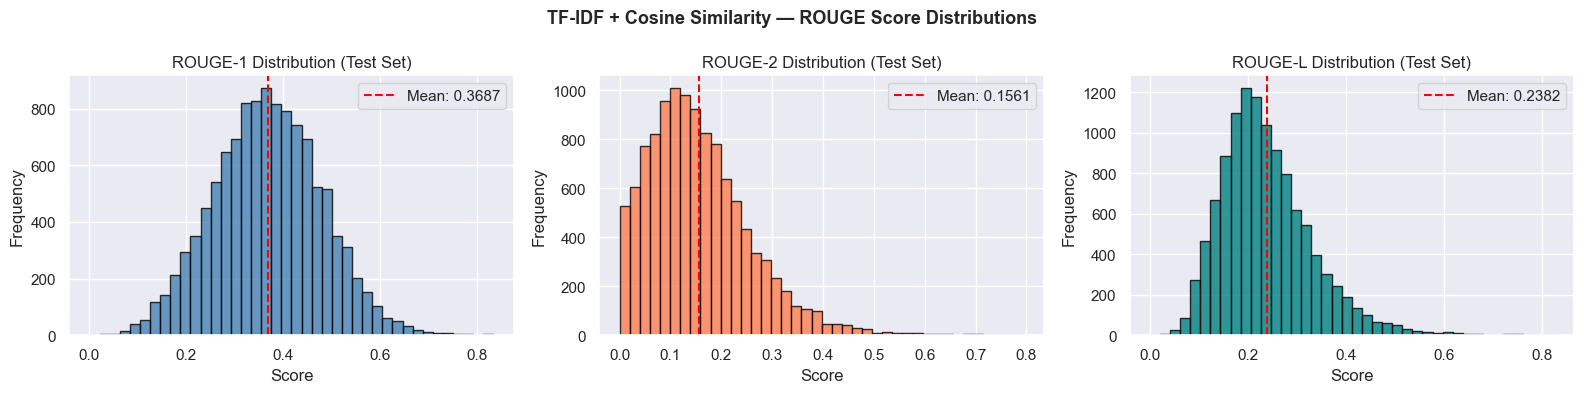

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, scores, label, color in zip(
    axes,
    [r1_test, r2_test, rL_test],
    ['ROUGE-1', 'ROUGE-2', 'ROUGE-L'],
    ['steelblue', 'coral', 'teal']
):
    ax.hist(scores, bins=40, color=color, edgecolor='black', alpha=0.8)
    ax.axvline(np.mean(scores), color='red', linestyle='--',
               label=f'Mean: {np.mean(scores):.4f}')
    ax.set_title(f'{label} Distribution (Test Set)')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('TF-IDF + Cosine Similarity — ROUGE Score Distributions', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [62]:
print("=" * 80)
print("REAL GENERATED SUMMARIES — TEST SET EXAMPLES")
print("=" * 80)

sample_indices = [0, 5, 10, 50, 100, 200, 500, 1000, 2000, 5000]

for idx in sample_indices:
    row     = test_df.iloc[idx]
    article = row['article']
    ref     = row['highlights']
    pred    = cosine_tfidf_summary(article, top_n=3)

    # rouge for this example
    s       = scorer_obj.score(pred, ref)
    r1      = s['rouge1'].fmeasure
    r2      = s['rouge2'].fmeasure
    rL      = s['rougeL'].fmeasure

    print(f"\n{'─'*80}")
    print(f"📰 ARTICLE SNIPPET (first 300 chars):")
    print(f"   {article[:300]}...")
    print(f"\n✅ REFERENCE SUMMARY:")
    for line in ref.strip().split('\n'):
        print(f"   {line}")
    print(f"\n🤖 PREDICTED SUMMARY:")
    for line in pred.strip().split('.'):
        if line.strip():
            print(f"   • {line.strip()}.")
    print(f"\n📊 ROUGE  →  R1: {r1:.4f}  |  R2: {r2:.4f}  |  RL: {rL:.4f}")

print(f"\n{'='*80}")

REAL GENERATED SUMMARIES — TEST SET EXAMPLES

────────────────────────────────────────────────────────────────────────────────
📰 ARTICLE SNIPPET (first 300 chars):
   (CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the cou...

✅ REFERENCE SUMMARY:
   Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
   Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .

🤖 PREDICTED SUMMARY:
   • (CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories.
   • The Palestinians signed the IC

In [63]:
import joblib
import json

# Save tfidf vectorizer settings as config (no fitting needed — 
# cosine pipeline fits a fresh tfidf per article)
tfidf_config = {
    'stop_words': 'english',
    'ngram_range': (1, 2),
    'max_features': 10000
}

with open('tfidf_config.json', 'w') as f:
    json.dump(tfidf_config, f)

print("Saved → tfidf_config.json")

Saved → tfidf_config.json


In [64]:
summarizer_code = '''
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def cosine_tfidf_summary(article, top_n=3):
    sentences = [s.strip() for s in article.split('.') 
                 if len(s.strip()) > 20]

    if len(sentences) == 0:
        return ""
    if len(sentences) <= top_n:
        return '. '.join(sentences) + '.'

    docs = sentences + [article]
    tfidf = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        max_features=10000
    )

    try:
        matrix = tfidf.fit_transform(docs)
    except:
        return '. '.join(sentences[:top_n]) + '.'

    article_vec   = matrix[-1]
    sentence_vecs = matrix[:-1]
    scores        = cosine_similarity(sentence_vecs, article_vec).flatten()

    for i in range(len(scores)):
        position = i / len(sentences)
        if position < 0.15:
            scores[i] *= 1.3
        elif position > 0.85:
            scores[i] *= 1.1

    top_indices = np.argsort(scores)[::-1][:top_n]
    top_indices = sorted(top_indices)

    summary = '. '.join([sentences[i] for i in top_indices]) + '.'
    return summary
'''

with open('summarizer.py', 'w') as f:
    f.write(summarizer_code)

print("Saved → summarizer.py")

Saved → summarizer.py


In [65]:
import pandas as pd
import numpy as np

metrics = {
    'method': ['TF-IDF + Cosine (Validation)', 'TF-IDF + Cosine (Test)', 'RF/XGB Baseline'],
    'rouge1': [round(np.mean(r1_scores), 4), round(np.mean(r1_test), 4), None],
    'rouge2': [round(np.mean(r2_scores), 4), round(np.mean(r2_test), 4), None],
    'rougeL': [round(np.mean(rL_scores), 4), round(np.mean(rL_test), 4), None],
    'rmse'  : [None, None, 0.0341],
    'r2'    : [None, None, 0.6382]
}

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv('model_metrics.csv', index=False)
print("Saved → model_metrics.csv")
print(metrics_df)

Saved → model_metrics.csv
                         method  rouge1  rouge2  rougeL    rmse      r2
0  TF-IDF + Cosine (Validation)  0.3772  0.1610  0.2438     NaN     NaN
1        TF-IDF + Cosine (Test)  0.3687  0.1561  0.2382     NaN     NaN
2               RF/XGB Baseline     NaN     NaN     NaN  0.0341  0.6382
